In [186]:
import pandas as pd
import numpy as np

In [187]:
df_log=pd.read_csv("Period_Log.csv")
df_user=pd.read_csv("User_Profile.csv")

In [188]:
df_log.head()

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,U00001,1,2024-02-13,33,NaN,Luteal,Heavy,9,Yes,6,5.4,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,3.7,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1
2,U00001,3,2024-04-19,34,33.0,Follicular,Heavy,8,No,5,5.7,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1
3,U00001,4,2024-05-23,31,34.0,Luteal,Light,3,No,8,5.2,6.7,8,8,2.5,82.0,8.50,Negative,9.0,0.949,0
4,U00001,5,2024-06-23,31,31.0,Luteal,Moderate,3,No,9,3.7,5.8,9,8,2.4,55.5,6.30,Negative,9.3,0.949,1


In [189]:
df_user.head()

,user_id,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00002,New Hampshire,32,26.6,Good,5–6 days/week,5.5,2.9,2.3,Weekly,No,0,0,5.7
2,U00003,Iowa,18,16.0,Poor,1–2 days/week,6.7,0.5,2.1,Never,No,1,0,3.1
3,U00004,Texas,30,24.7,Excellent,NaN,7.3,0.4,1.8,Occasionally,No,1,0,6.6
4,U00005,Delaware,32,29.2,Good,1–2 days/week,7.1,2.2,2.2,Occasionally,No,0,1,3.1


In [190]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

In [191]:
merged_data = pd.merge(df_log,df_user, on='user_id', how='left')

In [192]:
merged_data.head()

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,1,2024-02-13,33,NaN,Luteal,Heavy,9,Yes,6,5.4,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,3.7,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
2,U00001,3,2024-04-19,34,33.0,Follicular,Heavy,8,No,5,5.7,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
3,U00001,4,2024-05-23,31,34.0,Luteal,Light,3,No,8,5.2,6.7,8,8,2.5,82.0,8.50,Negative,9.0,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
4,U00001,5,2024-06-23,31,31.0,Luteal,Moderate,3,No,9,3.7,5.8,9,8,2.4,55.5,6.30,Negative,9.3,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1


In [193]:
merged_data.dropna(inplace=True)

In [194]:
merged_data.columns

Index(['user_id', 'cycle_number', 'start_date', 'cycle_length_days', 'prev_cycle_length', 'cycle_phase', 'flow_level', 'pain_level', 'pms_symptoms', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'ovulation_result', 'overall_health_score', 'log_consistency_score', 'prepared_before_period', 'state', 'age', 'bmi', 'diet_quality', 'exercise_frequency', 'sleep_hours', 'caffeine_intake', 'water_intake_liters', 'alcohol_consumption', 'smoking_status', 'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'], dtype='object')

In [195]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [196]:
encoding_columns=["cycle_phase","pms_symptoms","ovulation_result"]

In [197]:
encoder = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output=False,drop="first"), encoding_columns)
], remainder='passthrough')

In [198]:
encoded_array = encoder.fit_transform(merged_data)

In [199]:
ohe_feature_names = encoder.named_transformers_['ohe'].get_feature_names_out(encoding_columns)
remaining_cols = [col for col in merged_data.columns if col not in encoding_columns]
all_columns = list(ohe_feature_names) + remaining_cols

In [200]:
df_encoded = pd.DataFrame(encoded_array, columns=all_columns)

In [201]:
df_encoded.head()

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,flow_level,pain_level,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,0.0,0.0,0.0,0.0,U00001,2,2024-03-17,33,33.0,Light,2,8,3.7,4.6,7,8,2.6,126.1,2.79,9.4,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,0.0,0.0,0.0,0.0,U00001,3,2024-04-19,34,33.0,Heavy,8,5,5.7,5.1,5,5,6.8,131.1,1.7,6.7,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
2,1.0,0.0,0.0,0.0,U00001,4,2024-05-23,31,34.0,Light,3,8,5.2,6.7,8,8,2.5,82.0,8.5,9.0,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
3,1.0,0.0,0.0,0.0,U00001,5,2024-06-23,31,31.0,Moderate,3,9,3.7,5.8,9,8,2.4,55.5,6.3,9.3,0.949,1,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
4,1.0,0.0,0.0,0.0,U00001,6,2024-07-24,37,31.0,Moderate,6,6,4.9,4.5,6,7,4.6,107.8,7.17,7.7,0.949,0,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1


In [202]:
from sklearn.preprocessing import OrdinalEncoder

In [203]:
df_encoded["diet_quality"].unique()

array(['Good', 'Poor', 'Average', 'Excellent'], dtype=object)

In [204]:
ordinal_cols_order = {
    "flow_level":      ["Light", "Moderate", "Heavy"],
    "diet_quality":       ["Poor", "Average", "Good", "Excellent"],
    "alcohol_consumption":  ['Never', 'Occasionally', 'Weekly'],
    "exercise_frequency":[ "1–2 days/week", '3–4 days/week','5–6 days/week']
}

In [205]:
ordinal_cols   = list(ordinal_cols_order.keys())
category_order = list(ordinal_cols_order.values())

In [206]:
encoder = OrdinalEncoder(categories=category_order)
df_encoded[ordinal_cols] = encoder.fit_transform(df_encoded[ordinal_cols])

In [207]:
df_encoded[ordinal_cols].head()

,flow_level,diet_quality,alcohol_consumption,exercise_frequency
0,0.0,2.0,1.0,2.0
1,2.0,2.0,1.0,2.0
2,0.0,2.0,1.0,2.0
3,1.0,2.0,1.0,2.0
4,1.0,2.0,1.0,2.0


In [208]:
df_encoded["smoking_status"]=df_encoded["smoking_status"].map({"No":0,"Yes":1})

In [209]:
df_encoded.head()

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,flow_level,pain_level,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,0.0,0.0,0.0,0.0,U00001,2,2024-03-17,33,33.0,0.0,2,8,3.7,4.6,7,8,2.6,126.1,2.79,9.4,0.949,1,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
1,0.0,0.0,0.0,0.0,U00001,3,2024-04-19,34,33.0,2.0,8,5,5.7,5.1,5,5,6.8,131.1,1.7,6.7,0.949,1,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
2,1.0,0.0,0.0,0.0,U00001,4,2024-05-23,31,34.0,0.0,3,8,5.2,6.7,8,8,2.5,82.0,8.5,9.0,0.949,0,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
3,1.0,0.0,0.0,0.0,U00001,5,2024-06-23,31,31.0,1.0,3,9,3.7,5.8,9,8,2.4,55.5,6.3,9.3,0.949,1,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
4,1.0,0.0,0.0,0.0,U00001,6,2024-07-24,37,31.0,1.0,6,6,4.9,4.5,6,7,4.6,107.8,7.17,7.7,0.949,0,Rhode Island,34,26.0,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1


In [210]:
df_encoded.columns

Index(['cycle_phase_Luteal', 'cycle_phase_Menstrual', 'pms_symptoms_Yes', 'ovulation_result_Positive', 'user_id', 'cycle_number', 'start_date', 'cycle_length_days', 'prev_cycle_length', 'flow_level', 'pain_level', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'overall_health_score', 'log_consistency_score', 'prepared_before_period', 'state', 'age', 'bmi', 'diet_quality', 'exercise_frequency', 'sleep_hours', 'caffeine_intake', 'water_intake_liters', 'alcohol_consumption', 'smoking_status', 'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'], dtype='object')

In [211]:
#df_encoded.drop(["cycle_phase","pms_symptoms","ovulation_result"],inplace=True,axis=1)

In [212]:
df_encoded.to_csv(r"C:\Data Science Learning\Projects\regression-for-menstrual-pain\dataset\final_ds.csv",index=False)

In [213]:
df1 = df_encoded.copy(deep=True)

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric / irrelevant columns
drop_cols = [ 'start_date', 'state','prev_cycle_length','sleep_hours']
df2 = df1.drop(columns=drop_cols)

In [215]:
df2

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,user_id,cycle_number,cycle_length_days,flow_level,pain_level,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period,age,bmi,diet_quality,exercise_frequency,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,0.0,0.0,0.0,0.0,U00001,2,33,0.0,2,8,3.7,4.6,7,8,2.6,126.1,2.79,9.4,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1
1,0.0,0.0,0.0,0.0,U00001,3,34,2.0,8,5,5.7,5.1,5,5,6.8,131.1,1.7,6.7,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1
2,1.0,0.0,0.0,0.0,U00001,4,31,0.0,3,8,5.2,6.7,8,8,2.5,82.0,8.5,9.0,0.949,0,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1
3,1.0,0.0,0.0,0.0,U00001,5,31,1.0,3,9,3.7,5.8,9,8,2.4,55.5,6.3,9.3,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1
4,1.0,0.0,0.0,0.0,U00001,6,37,1.0,6,6,4.9,4.5,6,7,4.6,107.8,7.17,7.7,0.949,0,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12870,1.0,0.0,0.0,0.0,U02000,6,26,1.0,6,7,6.0,5.2,6,7,5.3,77.5,5.31,8.1,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7
12871,0.0,1.0,1.0,1.0,U02000,7,27,1.0,6,7,8.2,5.6,8,6,3.0,65.5,0.74,7.6,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7
12872,0.0,1.0,0.0,0.0,U02000,8,30,1.0,6,5,7.6,4.5,6,7,4.6,51.9,1.26,7.6,0.946,0,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7
12873,1.0,0.0,0.0,1.0,U02000,9,29,0.0,3,8,7.2,4.9,6,8,3.0,85.3,8.99,8.8,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7


In [216]:
pain_df = df2[['user_id', 'cycle_number', 'pain_level']].copy()

In [217]:
pain_df

,user_id,cycle_number,pain_level
0,U00001,2,2
1,U00001,3,8
2,U00001,4,3
3,U00001,5,3
4,U00001,6,6
...,...,...,...
12870,U02000,6,6
12871,U02000,7,6
12872,U02000,8,6
12873,U02000,9,3


In [218]:
df3 = df2.merge(pain_df, on=['user_id', 'cycle_number'])

In [219]:
df3

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,user_id,cycle_number,cycle_length_days,flow_level,pain_level_x,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period,age,bmi,diet_quality,exercise_frequency,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline,pain_level_y
0,0.0,0.0,0.0,0.0,U00001,2,33,0.0,2,8,3.7,4.6,7,8,2.6,126.1,2.79,9.4,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,2
1,0.0,0.0,0.0,0.0,U00001,3,34,2.0,8,5,5.7,5.1,5,5,6.8,131.1,1.7,6.7,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,8
2,1.0,0.0,0.0,0.0,U00001,4,31,0.0,3,8,5.2,6.7,8,8,2.5,82.0,8.5,9.0,0.949,0,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,3
3,1.0,0.0,0.0,0.0,U00001,5,31,1.0,3,9,3.7,5.8,9,8,2.4,55.5,6.3,9.3,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,3
4,1.0,0.0,0.0,0.0,U00001,6,37,1.0,6,6,4.9,4.5,6,7,4.6,107.8,7.17,7.7,0.949,0,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12870,1.0,0.0,0.0,0.0,U02000,6,26,1.0,6,7,6.0,5.2,6,7,5.3,77.5,5.31,8.1,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,6
12871,0.0,1.0,1.0,1.0,U02000,7,27,1.0,6,7,8.2,5.6,8,6,3.0,65.5,0.74,7.6,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,6
12872,0.0,1.0,0.0,0.0,U02000,8,30,1.0,6,5,7.6,4.5,6,7,4.6,51.9,1.26,7.6,0.946,0,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,6
12873,1.0,0.0,0.0,1.0,U02000,9,29,0.0,3,8,7.2,4.9,6,8,3.0,85.3,8.99,8.8,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,3


In [220]:
print(df2['pain_level'].dtype)

object


In [221]:
import pandas as pd

df2['pain_level'] = pd.to_numeric(df2['pain_level'], errors='coerce')

In [222]:
print(df2['pain_level'].dtype)

int64


In [223]:
import numpy as np

df_new = df2.select_dtypes(include=[np.number]).copy()

# Replace inf values
df_new= df_new.replace([np.inf, -np.inf], np.nan)

# Drop missing values in pain
df_new = df_new.dropna(subset=['pain_level'])

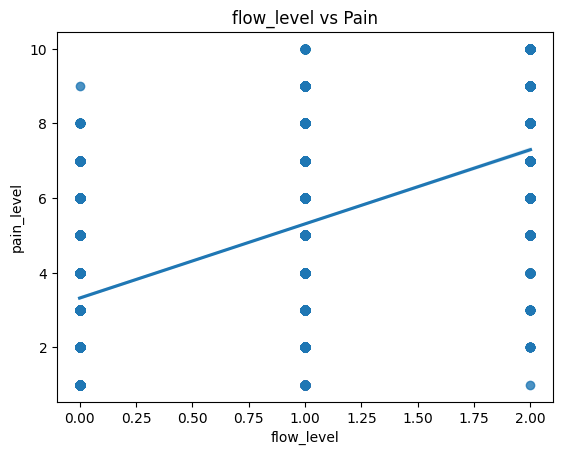

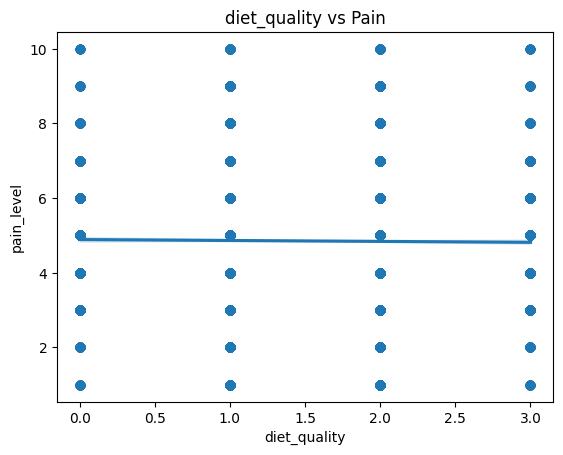

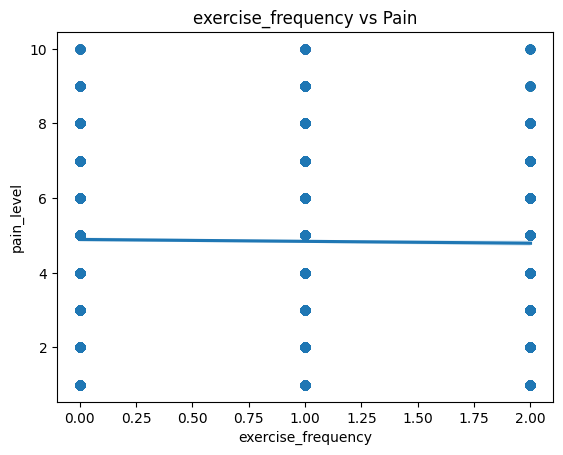

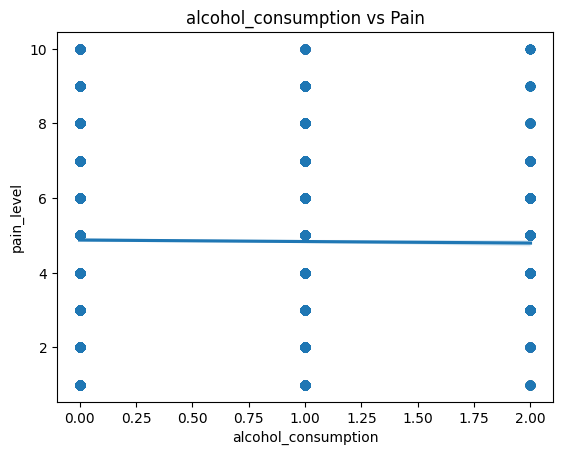

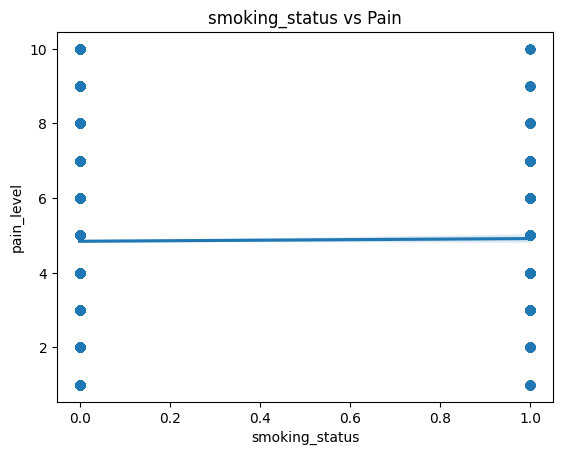

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df_new.columns:
    if col not in ['user_id', 'cycle_number', 'pain_level']:
        sns.regplot(x=col, y='pain_level', data=df_new)
        plt.title(f"{col} vs Pain")
        plt.show()

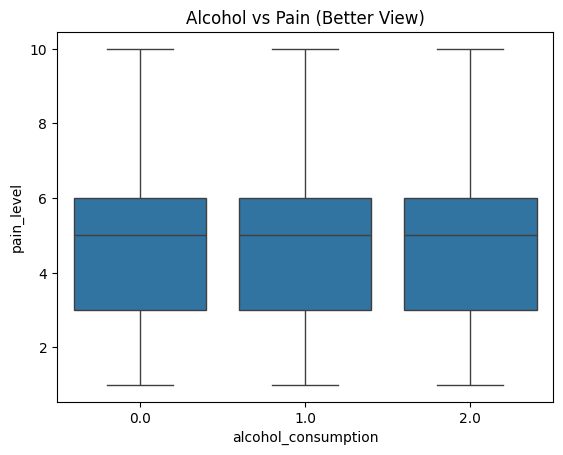

In [225]:
sns.boxplot(x='alcohol_consumption', y='pain_level', data=df2)
plt.title("Alcohol vs Pain (Better View)")
plt.show()

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric / irrelevant columns
drop_cols = ['user_id', 'start_date', 'state','prev_cycle_length','sleep_hours','pain_level']
df_numeric = df_encoded.drop(columns=drop_cols)

|rij| < 0.9 : No Multicollinearity                                            
|rij| >= 0.9 : Indicates Multicollinearity Problem

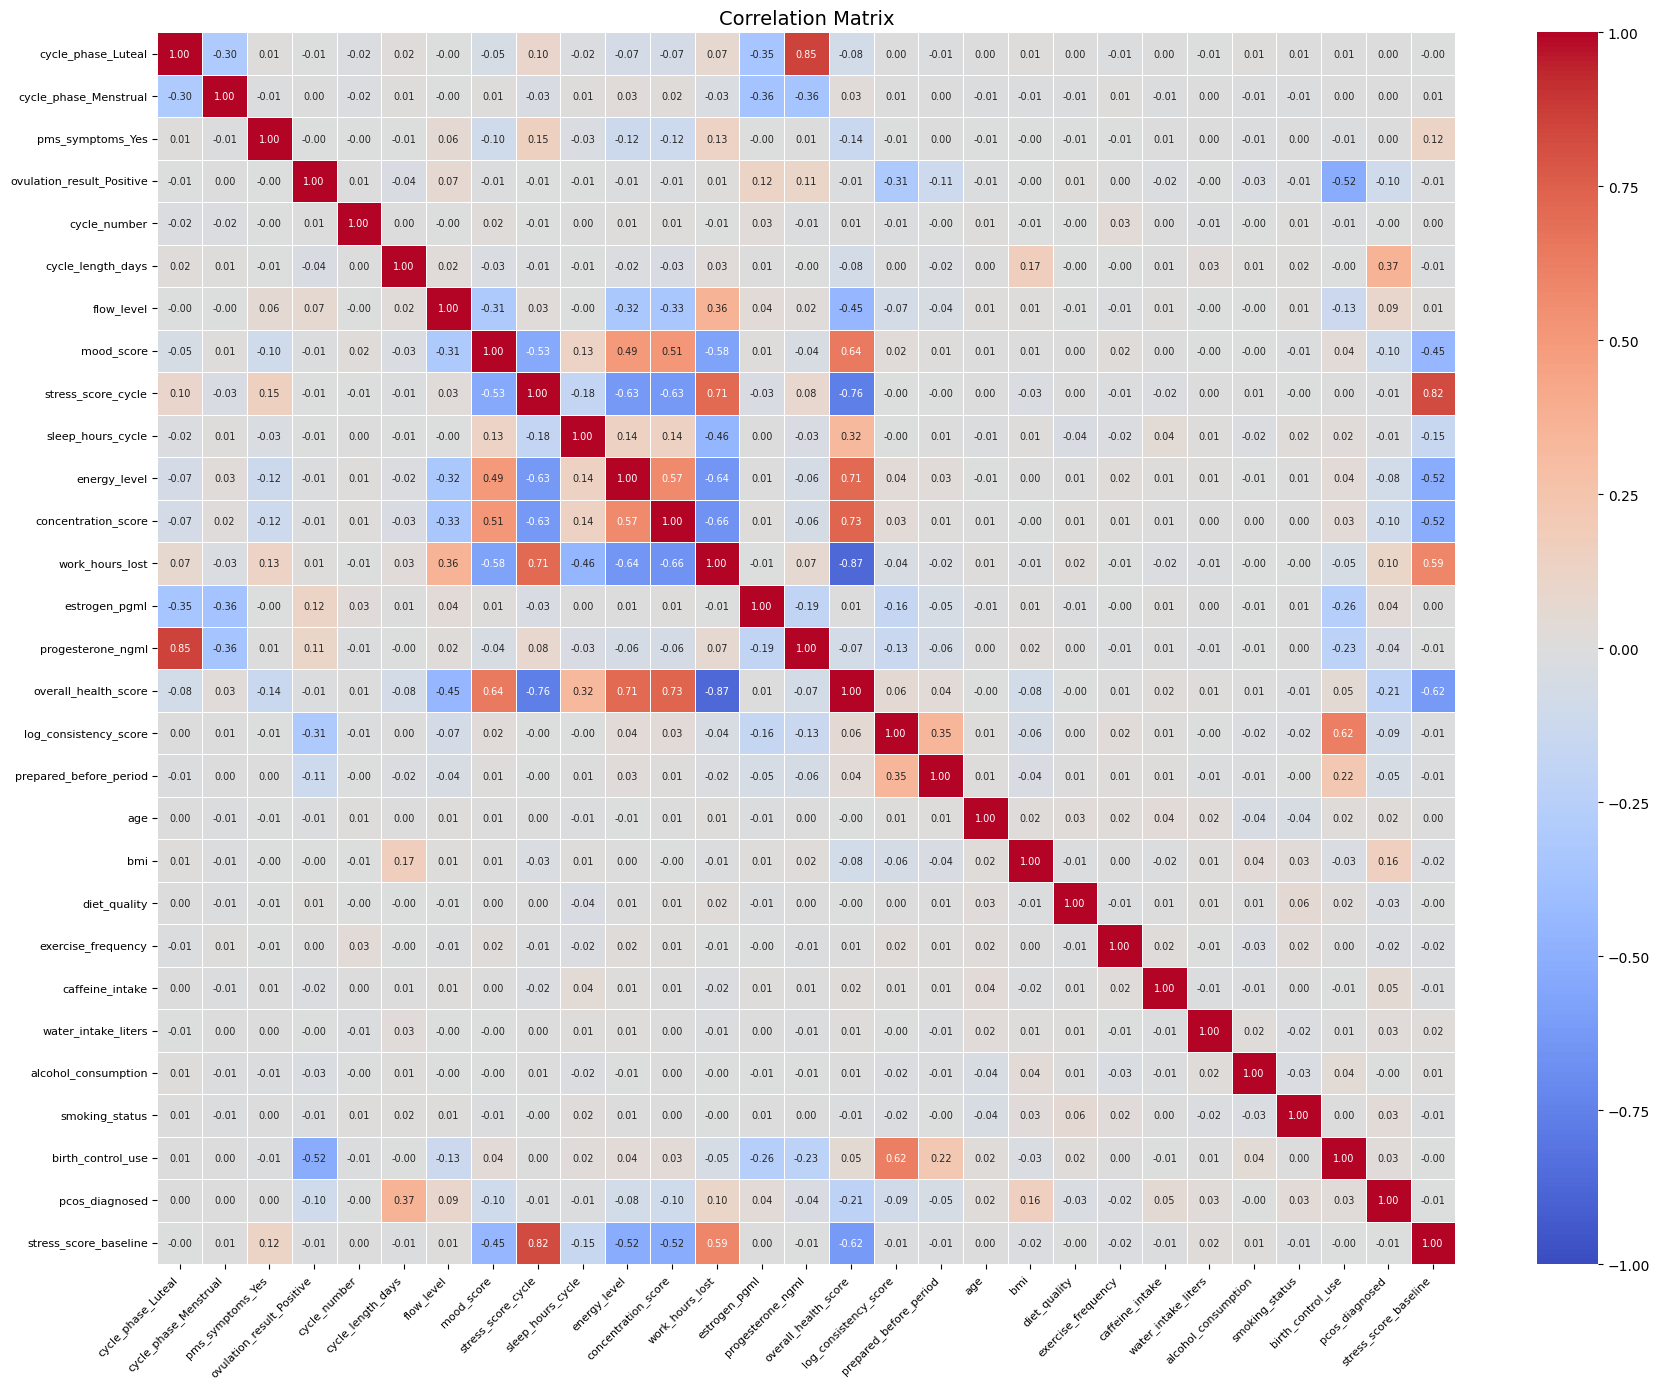

In [227]:
# Correlation Matrix (better for mixed-scale columns like yours)
corr_matrix = df_numeric.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5,
            annot_kws={"size": 7},
            vmin=-1, vmax=1)          # fixes scale between -1 and 1
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [228]:
df_numeric.columns

Index(['cycle_phase_Luteal', 'cycle_phase_Menstrual', 'pms_symptoms_Yes', 'ovulation_result_Positive', 'cycle_number', 'cycle_length_days', 'flow_level', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'overall_health_score', 'log_consistency_score', 'prepared_before_period', 'age', 'bmi', 'diet_quality', 'exercise_frequency', 'caffeine_intake', 'water_intake_liters', 'alcohol_consumption', 'smoking_status', 'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'], dtype='object')

K < 100 : No Serious Multicollinearity Problem                                        
100 <= K <= 1000 : Moderate to Strong Multicollinearity                                    
K > 1000 : Severe Multicollinearity Problem

In [229]:
# EIGEN ANALYSIS SYSTEM

# Use your cleaned numeric dataframe
X = df_numeric.copy()

# Ensure numeric only
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()

# Correlation matrix
corr_matrix = X.corr()

# Eigenvalues of correlation matrix
eigenvalues = np.linalg.eigvals(corr_matrix)

# Sort eigenvalues (important)
eigenvalues = np.sort(eigenvalues)

# Condition number (K)
condition_number = eigenvalues[-1] / eigenvalues[0]

print("Eigenvalues:\n", eigenvalues)
print("\nCondition Number (K):", condition_number)

Eigenvalues:
 [0.07546508 0.10999299 0.123126   0.21555908 0.26841133 0.3804597
 0.38685362 0.4267959  0.52926199 0.57406147 0.66209295 0.84452296
 0.88312826 0.92850892 0.94377996 0.96233855 0.96839047 0.99053505
 0.99969081 1.03868771 1.06104251 1.071978   1.09200406 1.15178947
 1.31166045 1.55617238 2.06021967 2.30612415 5.07734652]

Condition Number (K): 67.28073915061428


In [230]:
condition_index = np.sqrt(eigenvalues[-1] / eigenvalues)

ci_table = pd.DataFrame({
    "Eigenvalue": eigenvalues,
    "Condition Index": condition_index
})

print(ci_table.sort_values(by="Condition Index", ascending=False))

    Eigenvalue  Condition Index
0     0.075465         8.202484
1     0.109993         6.794162
2     0.123126         6.421604
3     0.215559         4.853279
4     0.268411         4.349286
5     0.380460         3.653121
6     0.386854         3.622806
7     0.426796         3.449120
8     0.529262         3.097298
9     0.574061         2.973988
10    0.662093         2.769229
11    0.844523         2.451956
12    0.883128         2.397764
13    0.928509         2.338435
14    0.943780         2.319439
15    0.962339         2.296965
16    0.968390         2.289777
17    0.990535         2.264037
18    0.999691         2.253645
19    1.038688         2.210935
20    1.061043         2.187520
21    1.071978         2.176334
22    1.092004         2.156286
23    1.151789         2.099577
24    1.311660         1.967468
25    1.556172         1.806299
26    2.060220         1.569863
27    2.306124         1.483806
28    5.077347         1.000000


In [231]:
# VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Copy data
X = df_numeric.copy()

# Convert all columns to numeric (invalid parsing → NaN)
X = X.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN (important for VIF stability)
X = X.dropna()

# Add your intercept column
X["const"] = 22.699

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Remove intercept from interpretation
vif_result = vif_data[vif_data["Variable"] != "const"]

print(vif_result.sort_values(by="VIF", ascending=False))

                     Variable       VIF
15       overall_health_score  9.371046
8          stress_score_cycle  6.736805
12            work_hours_lost  5.390362
14          progesterone_ngml  4.811652
0          cycle_phase_Luteal  4.800253
28      stress_score_baseline  3.211025
26          birth_control_use  2.447817
11        concentration_score  2.311311
10               energy_level  2.188592
6                  flow_level  2.105878
16      log_consistency_score  1.799998
7                  mood_score  1.762976
13              estrogen_pgml  1.749726
1       cycle_phase_Menstrual  1.619964
9           sleep_hours_cycle  1.591846
27             pcos_diagnosed  1.411202
3   ovulation_result_Positive  1.382011
5           cycle_length_days  1.178938
17     prepared_before_period  1.141001
19                        bmi  1.094285
2            pms_symptoms_Yes  1.028716
24        alcohol_consumption  1.013805
25             smoking_status  1.010966
18                        age  1.010686


VIF >= 5 : Multicollinearity Problem                                          
VIF >= 10 : Severe Multicollinearity

In [232]:
X

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,cycle_number,cycle_length_days,flow_level,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,overall_health_score,log_consistency_score,prepared_before_period,age,bmi,diet_quality,exercise_frequency,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline,const
0,0.0,0.0,0.0,0.0,2,33,0.0,8,3.7,4.6,7,8,2.6,126.1,2.79,9.4,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,22.699
1,0.0,0.0,0.0,0.0,3,34,2.0,5,5.7,5.1,5,5,6.8,131.1,1.70,6.7,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,22.699
2,1.0,0.0,0.0,0.0,4,31,0.0,8,5.2,6.7,8,8,2.5,82.0,8.50,9.0,0.949,0,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,22.699
3,1.0,0.0,0.0,0.0,5,31,1.0,9,3.7,5.8,9,8,2.4,55.5,6.30,9.3,0.949,1,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,22.699
4,1.0,0.0,0.0,0.0,6,37,1.0,6,4.9,4.5,6,7,4.6,107.8,7.17,7.7,0.949,0,34,26.0,2.0,2.0,1.5,2.0,1.0,0,1,1,4.1,22.699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12870,1.0,0.0,0.0,0.0,6,26,1.0,7,6.0,5.2,6,7,5.3,77.5,5.31,8.1,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,22.699
12871,0.0,1.0,1.0,1.0,7,27,1.0,7,8.2,5.6,8,6,3.0,65.5,0.74,7.6,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,22.699
12872,0.0,1.0,0.0,0.0,8,30,1.0,5,7.6,4.5,6,7,4.6,51.9,1.26,7.6,0.946,0,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,22.699
12873,1.0,0.0,0.0,1.0,9,29,0.0,8,7.2,4.9,6,8,3.0,85.3,8.99,8.8,0.946,1,24,20.1,2.0,0.0,2.3,2.3,1.0,0,1,0,6.7,22.699


In [233]:
# Removing Regressor with highest VIF
X = df_numeric.drop(columns=["overall_health_score"])

After removing the regressor with highest VIF, the VIFs of the remaining regressors increases hence directly removing "overall_health_score" is not an option



In [234]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X.apply(pd.to_numeric, errors='coerce').dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

                     Variable         VIF
15      log_consistency_score  531.823038
5           cycle_length_days  163.809142
8          stress_score_cycle   64.383584
11        concentration_score   58.611111
27      stress_score_baseline   49.032660
9           sleep_hours_cycle   43.504446
7                  mood_score   38.574973
10               energy_level   36.052954
18                        bmi   31.919464
17                        age   28.772916
12            work_hours_lost   26.878288
13              estrogen_pgml   22.582641
14          progesterone_ngml   14.323096
22        water_intake_liters   12.116622
0          cycle_phase_Luteal    8.690961
4                cycle_number    5.609166
19               diet_quality    4.877705
21            caffeine_intake    3.956782
6                  flow_level    3.839076
25          birth_control_use    3.120175
16     prepared_before_period    3.009567
3   ovulation_result_Positive    2.973465
20         exercise_frequency    2